In [1]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import pandas as pd
import numpy as np
import pathfinder_data
import matplotlib.pyplot as plt
%matplotlib widget

from scipy.linalg import block_diag
import scipy as sc
import sympy as sp
import jax
import jax.numpy as jnp

import rover as rover_class
import grid_world

# Satellites

## Set-up satellite constellation

In [2]:
# Pathfinder Orbit
# epoch_0 = pnt.SpiceInterface.string_to_tai("2030/10/01 00:00:00.000 UTC")
# N_sat = 1
# N_planes = 1
# N_sat_plane = N_sat // N_planes
# # sma = 5740.0  # [km] Semi-major axis
# # ecc = [0.58]  # [-] Eccentricity
# # inc = np.deg2rad([54.856])  # [rad] Inclination
# # raan = np.deg2rad([0])  # [rad] Right ascension of the ascending node
# # aop = np.deg2rad([86.322])  # [rad] Argument of periapsis
# # ma = np.deg2rad([180])  # [rad] Mean anomaly
# # in OP frame
# sma = 5740.0  # [km] Semi-major axis
# ecc = [0.58]  # [-] Eccentricity
# inc = [0.948821236448819]  # [rad] Inclination
# raan = [-1.67563774150938]  # [rad] Right ascension of the ascending node
# aop = [1.0327264897389]  # [rad] Argument of periapsis
# ma = np.deg2rad([180])  # [rad] Mean anomaly

In [3]:
# ****************************************************************************************
# Satellite constellation - Inspired Keidai's and Guillem's IEEE work
# ****************************************************************************************

# set-up orbit epoch, number of satellites, number of planes, and number of satellites per plane
epoch_0 = pnt.SpiceInterface.string_to_tai("2025/10/02 00:00:00.000 UTC")
N_sat = 4
N_planes = 2
N_sat_plane = N_sat // N_planes
# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
sma = 6142.4  # [km] Semi-major axis
ecc = [0.6, 0.6]  # [-] Eccentricity
inc = np.deg2rad([57.7, 57.7])  # [rad] Inclination
raan = np.deg2rad([0, 180])  # [rad] Right ascension of the ascending node
aop = np.deg2rad([90, 90])  # [rad] Argument of periapsis
ma = np.deg2rad([180, 0])  # [rad] Mean anomaly

# # old constelation
# sma = 6142.4  # [km] Semi-major axis
# ecc = [0.001, 0.6, 0.6]  # [-] Eccentricity
# inc = np.deg2rad([0.001, 57.7, 57.7])  # [rad] Inclination
# raan = np.deg2rad([0, -90, 0])  # [rad] Right ascension of the ascending node
# aop = np.deg2rad([-45, -90, 90])  # [rad] Argument of periapsis
# ma = np.deg2rad([-20, 180, 0])  # [rad] Mean anomaly


# group the together and create the initial state vectors
coe_mi = np.zeros((N_sat, 6))
rv0_moon_sat_mi = np.zeros((N_sat, 6))
for i_pl in range(N_planes):
    for i_spl in range(N_sat_plane):
        i_sat = i_pl * N_sat_plane + i_spl
        coe_mi[i_sat] = np.array(
            [sma, ecc[i_pl], inc[i_pl], raan[i_pl], aop[i_pl], ma[i_spl]]
        )
        rv0_moon_sat_mi[i_sat] = pnt.classical_to_cartesian(coe_mi[i_sat], pnt.MU_MOON)

# Time discretization
# TODO: this is where we can change things up depending on the simulation scenario
sma = coe_mi[0, 0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
# NOTE: 3 days of simulation time takes 2 minutes and 36 seconds of computation time with the current time step
N_days = 0.5  # [-] Number of days
tf = N_days * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body with Earth, no Sun included)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
# dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = np.zeros((N_sat, N_t, 6))
rv_moon_sat_pa = np.zeros((N_sat, N_t, 6))
for i_sat in range(N_sat):
    rv_moon_sat_mi[i_sat] = dynamics.propagate(rv0_moon_sat_mi[i_sat], epoch_0, epochs)
    rv_moon_sat_pa[i_sat] = pnt.CoordConverter.convert(
        epochs, rv_moon_sat_mi[i_sat], pnt.MI, pnt.PA
    )

Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


## Pretty plot

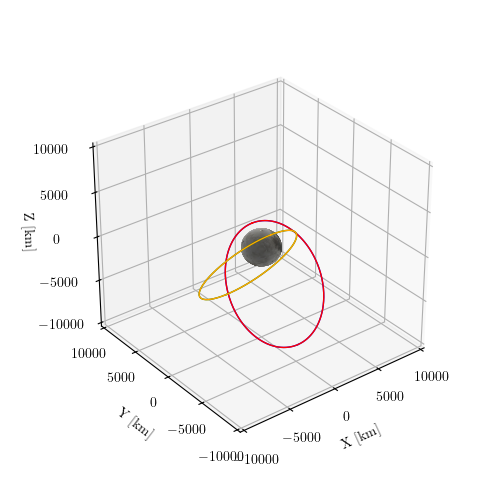

In [4]:
# Attitude
fig = pnt.plots.Plot3D(figsize=(5, 5), elev=31, azim=-128)
fig.plot_surface(pnt.MOON, scale=3)

# e_moon_sun = rv_moon_sun_mi[0, 0:3] / np.linalg.norm(rv_moon_sun_mi[0, 0:3])
# e_moon_earth = rv_moon_earth_mi[0, 0:3] / np.linalg.norm(rv_moon_earth_mi[0, 0:3])
orbit_color = np.array(["blue", "red", "green", "orange"])

for i_sat in range(N_sat):
    plt.plot(
        rv_moon_sat_mi[i_sat, :, 0],
        rv_moon_sat_mi[i_sat, :, 1],
        rv_moon_sat_mi[i_sat, :, 2],
        color=orbit_color[i_sat],
        linewidth=1,
    )



## Satellite Observables

In [5]:
def get_pseudorange_measurement(satpos, x_est, use_Gnoise):
    # simulate pseudorange measurements from a given satellite
    # likely inputs: true satellite state, true receiver state
    # we can already add noise to the measurements here, or outside like in the MATLAB simulator
    # the pseudorange error model is the same as what we had from the endurance work
    # also let's get the Jacobian here too (maybe JAX can come in handy!)
    
    # x_est is a 1x3 np array and satpos is a Nx3 np array
    n_meas = satpos.shape[0]
    los = np.tile(x_est, (n_meas, 1)) - satpos # Nx3
    range = np.linalg.norm(los, axis=1) # Nx1
    if use_Gnoise:
        Gnoise = np.random.normal(0.0, 1.0, size=n_meas)
        range += Gnoise
    print('los = ', los)
    print('range = ', range)
    print('tile = ', np.tile(range, (1, 3)))
    e = los / np.tile(range, (1, 3)) # Nx3
    H = e
    return range, H

def get_pseudorange_rate_measurement():
    # simulate pseudorange rate measurements from a given satellite
    # now the error model for this... is a little different and we need to think about it more
    # plus we need this for the ION paper too
    raise NotImplementedError

def get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi, fcar=2492.028e6, LNA_NF_dB = 1, rec_Tsys_K = 113):
    # assume that the satellite is always pointing towards the center of the moon
    # we are going to need some antenna gain patterns for this, but we can fish them out from the MATLAB simulator
    # simulate the carrier-to-noise ratio for a given satellite
    c = 299792458
    k_dBW_K_Hz = -228.6
    FSPL_dB = 20*np.log10(4*np.pi*dist_m*fcar/c)
    Prx = EIRP_beta_dBW - FSPL_dB
    Teq_K = rec_Tsys_K + 290*(10**(LNA_NF_dB/10)-1)
    Teq_dB = 10*np.log10(Teq_K)
    g_over_T = rec_gain_theta_dBi - Teq_dB
    cn0_dBHz = Prx + g_over_T - k_dBW_K_Hz
    cn0 = 10**(cn0_dBHz/10)
    return cn0

def mcmf_to_enu(lat_user, lon_user):
    # convert from MCMF to ENU coordinates
    # lat_user = rover latitude in radians (1x1)
    # lon_user = rover longitude in radians (1x1)
    phi, lmda = lat_user, lon_user
    M = np.array([
        [-np.sin(lmda), np.cos(lmda), 0],
        [-np.cos(lmda)*np.sin(phi), -np.sin(lmda)*np.sin(phi), np.cos(phi)],
        [np.cos(lmda)*np.cos(phi), np.sin(lmda)*np.cos(phi), np.sin(phi)]
    ])
    return M
    
def get_elev_azim(M, mcmf_sat, user_mcmf_rv):
    # get the elevation and azimuth of a given satellite (VALIDATED WITH PATHFINDER ORBIT)
    # M = output of mcmf_to_enu function (6x6)
    # mcmf_sat = Nx6 state vector of satellite (N is number of satellites)
    # user_mcmf_rv = 1x6 state vector of rover

    # note that mcmf_sat is a N_sat X N_time X x 6 array
    lent = mcmf_sat.shape[1]
    enu_sat = np.zeros(mcmf_sat.shape)
    el_sat, az_sat = np.zeros((mcmf_sat.shape[0], lent)), np.zeros((mcmf_sat.shape[0], lent))

    for sat_idx in range(mcmf_sat.shape[0]):
        for t in range(mcmf_sat.shape[1]):  
            enu_sat[sat_idx, t, :] = block_diag(M, M) @ (mcmf_sat[sat_idx,t,:] - user_mcmf_rv)
            norm_enu_sat = np.linalg.norm(enu_sat[sat_idx, t, :3])

            el_sat[sat_idx,t] = np.degrees(np.arcsin(enu_sat[sat_idx, t, 2] / norm_enu_sat))  # up

            norm_east, norm_north = enu_sat[sat_idx, t, 0] / norm_enu_sat, enu_sat[sat_idx, t, 1] / norm_enu_sat
            az_sat_rad = np.mod(np.arctan2(norm_east, norm_north), 2 * np.pi)
            az_sat[sat_idx, t] = np.degrees(az_sat_rad)

    return el_sat, az_sat


### Testing (Kaila)

In [6]:
# TESTING
# Constants used for testing
EIRP_beta_dBW = 14
rec_gain_theta_dBi = 3
mcmf_sat = np.array([[-0.4513, 4.3380, -7.9516, -0.0005, -0.0001, 0.0],
                     [-0.4517, 4.3379, -7.9517, -0.0005, -0.0001, 0.0]]) * 1e3
user_mcmf_rv = np.array([0.0, 0.0, -1.7374, 0.0, 0.0, 0.0]) * 1e3
user_mcmf_rv = np.tile(user_mcmf_rv, (mcmf_sat.shape[0], 1))
lent = 2 #78047
lat_user = -1.5708
lon_user = 0.0

# print(mcmf_sat[:, :3].shape)
# print(user_mcmf_rv[0, :3])
# range, H = get_pseudorange_measurement(mcmf_sat[:, :3], user_mcmf_rv[0, :3], use_Gnoise = False)
# print('range = ', range)
# print('H = ', H)

dist_m = np.linalg.norm(mcmf_sat[:, :3] - user_mcmf_rv[:, :3], axis=1) * 1000
cn0 = get_CN0(dist_m, EIRP_beta_dBW, rec_gain_theta_dBi)
print(cn0)
print(dist_m)
print(mcmf_sat[:3])

M = mcmf_to_enu(lat_user, lon_user)
el_sat, az_sat = get_elev_azim(M, mcmf_sat, user_mcmf_rv, lent)
print(el_sat)
print(az_sat)

[30693.29485609 30692.90268395]
[7591982.43741383 7592030.93974201]
[[-4.5130e+02  4.3380e+03 -7.9516e+03 -5.0000e-01 -1.0000e-01  0.0000e+00]
 [-4.5170e+02  4.3379e+03 -7.9517e+03 -5.0000e-01 -1.0000e-01  0.0000e+00]]


TypeError: get_elev_azim() takes 3 positional arguments but 4 were given

# Rover

In [7]:
def p_norm_trajectory(x, p, a = 1, b = 1, c = 1):
    """ Generate a p-norm trajectory for given x values"""
    y_array = np.zeros(len(x))
    # solve for y
    for i in range(len(x)):
        y = sp.symbols('y')
        # p_norm equation
        y_array[i] = ((c**p - (x[i]/a)**p)**(1/p))*b
    # return y

    
    return y_array

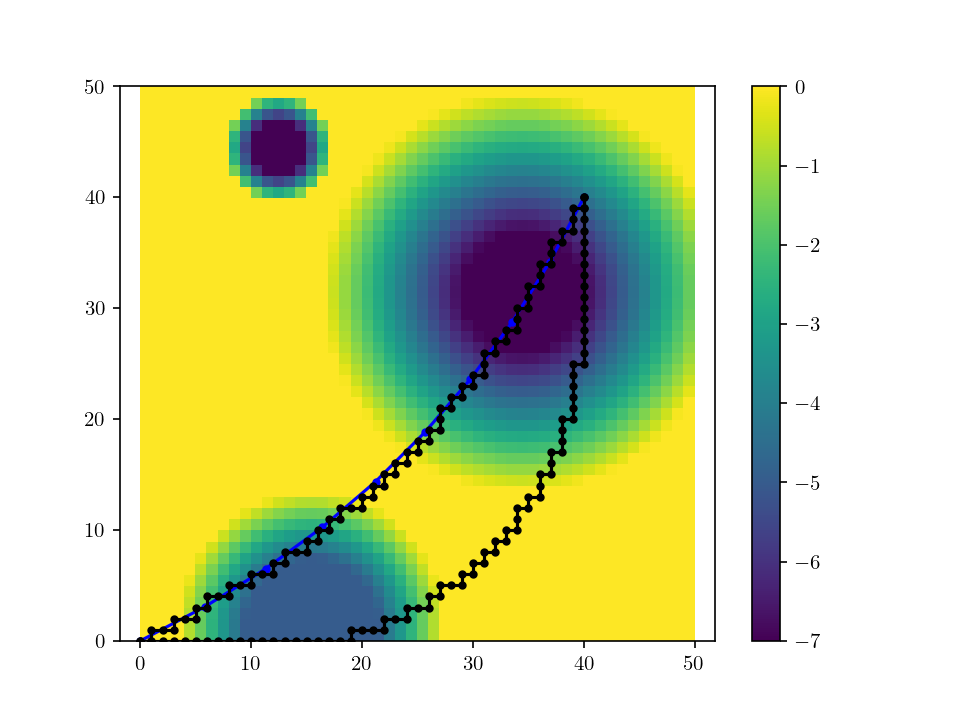

In [37]:
# rover
# assume the user is at the Poincare crater (in rad)
lat_user = np.deg2rad(-59.12448)
lon_user = np.deg2rad(161.05104)
# can initialize the rover with the desired initial location
rover = rover_class.Rover_Agent([lat_user, lon_user])
# TODO: need to make the state actually the rover state
rover_state = rover.rover_loc

# create a grid (specify number of cells and cell resolution)
grid_env = grid_world.GridWorld(50, 1, N_t, rover.rover_loc)
coeffs, traj = grid_env.generate_deterministic_trajectory([0, 0, 0], [40, 40, 10], 1.3)
coeffs2, traj2 = grid_env.generate_deterministic_trajectory([0, 0, 0], [40, 40, 10], 3)
# if you want to get the grid, use
# grid = grid_env.grid()

# let's add some craters (if you do not specify location, they will be randomly placed)
crater = grid_env.create_crater(12, 5)
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(5, 7)
grid_env.add_crater(crater, slope_factor=0.5)

crater = grid_env.create_crater(18, 7)
grid_env.add_crater(crater, slope_factor=0.3)

# plot the grid
fig, ax = grid_env.plot_grid_elev()
ax.plot(traj[:,0], traj[:,1], '.-', color='blue', label = 'Trajectories')
traj_disc = grid_env.discretize_traj(traj)
traj_disc2 = grid_env.discretize_traj(traj2)
# plot the discretized trajectory
ax.plot(traj_disc[:,0], traj_disc[:,1], '.-', color='black', label = 'Discretized Trajectory')
ax.plot(traj_disc2[:,0], traj_disc2[:,1], '.-', color='black', label = 'Discretized Trajectory')

In [38]:
grid_env.moon_pa_origin

array([ -843.27271255,   289.52207353, -1491.18304081])

[[-0.32472574 -0.94580822  0.        ]
 [-0.81177229  0.27870699  0.51317459]
 [-0.48536475  0.166641   -0.85828424]]
[ -843.27271255   289.52207353 -1491.18304081]
[ 1.14193797e-14 -1.36441528e-14  1.73740000e+03]


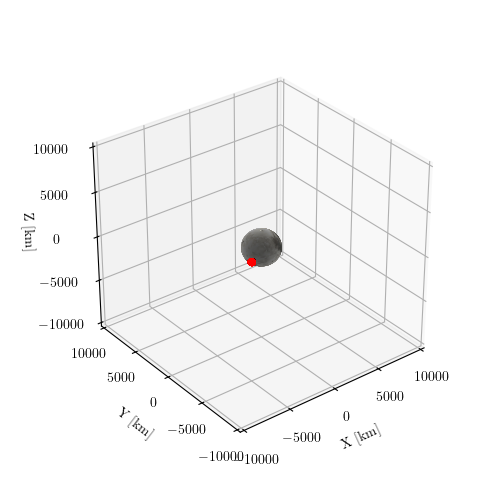

In [39]:
# roughly estimate the conversion, although...
grid_coords, grid_lat_long= grid_env.grid_PA_coords(lat_user, lon_user)

fig = pnt.plots.Plot3D(figsize=(5, 5), elev=31, azim=-128)
fig.plot_surface(pnt.MOON, scale=3)

# ax = fig.add_subplot(111, projection='3d')
fig.ax.scatter(grid_coords[:,:,0], grid_coords[:,:,1], grid_coords[:,:,2], color='red')

# fig = plt.figure()
# plt.plot(grid_lat_long[:,0], grid_lat_long[:,1], '.-', color='blue', label = 'Grid')
# ax.scatter(grid_coords[:,:,0], grid_coords[:,:,1], grid_coords[:,:,2], color='red')


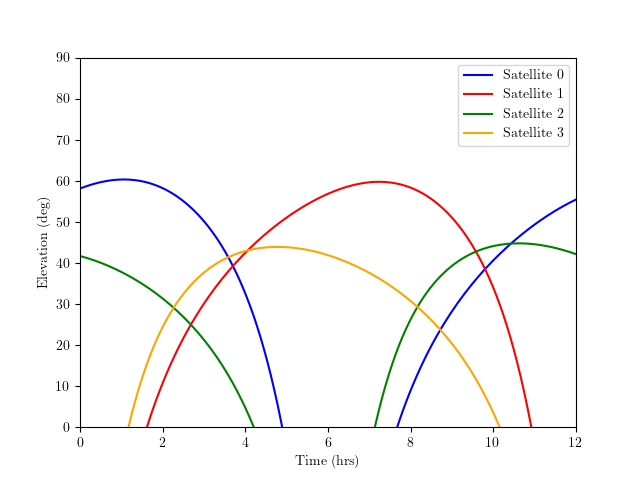

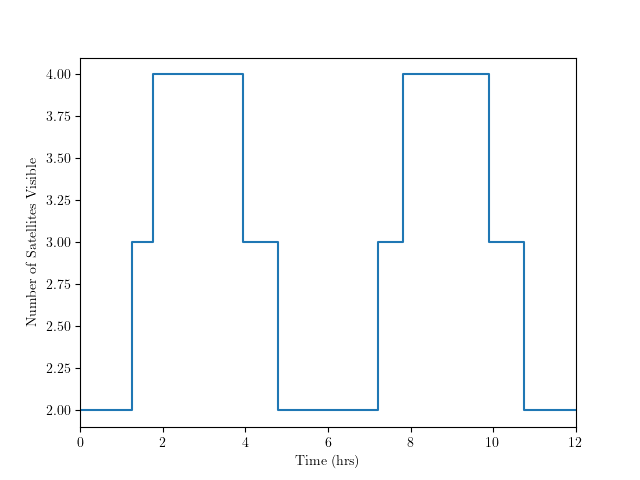

In [ ]:
# # rv_moon_sat_mi --> M satellites, N time steps, 6 states
# # assume the user is at the Poincare crater (in rad)
# lat_user = np.deg2rad(-59.12448)
# lon_user = np.deg2rad(161.05104)

# # assume the user is at the South Pole (in rad)
# # lat_user = np.deg2rad(-90)
# # lon_user = np.deg2rad(0)

# # convert to user coordinates in Moon-Centered Moon-Fixed frame
# user_loc = rover_class.latlong_to_MoonPA(lat_user, lon_user)
user_rv = np.array([rover_state[0], rover_state[1], rover_state[2], 0, 0, 0])

# based on user location, get the elevation of each satellite
M = mcmf_to_enu(lat_user, lon_user)
lent = len(tspan)
el_sat, az_sat = get_elev_azim(M, rv_moon_sat_pa, user_rv)

# plot the elevation for each of the satellites
plt.figure()
for i_sat in range(N_sat):
    plt.plot(tspan/3600, el_sat[i_sat], label='Satellite ' + str(i_sat), color=orbit_color[i_sat])
plt.xlabel('Time (hrs)')
plt.ylabel('Elevation (deg)')
plt.legend()
plt.ylim(0, 90)
plt.xlim(0, tf/3600)
plt.show()

# get the number of satellites that are visible at each time step
# if elevation is greater than 5, then the satellite is visible
visible_sat = np.zeros((N_sat, lent))
for i_sat in range(N_sat):
    visible_sat[i_sat] = el_sat[i_sat] > 5

tot_visible = np.sum(visible_sat, axis=0)

# plot as a step function
plt.figure()
plt.step(tspan/3600, tot_visible)
plt.xlabel('Time (hrs)')
plt.ylabel('Number of Satellites Visible')
plt.xlim(0, tf/3600)
plt.show()


## Analysis of GDOP, Visibility, Ground Track, etc...

In [ ]:
def get_GDOP():
    # A function that computes the GDOP of a given set of satellites at a single time instance
    raise NotImplementedError

def plot_ground_track():
    # A function that plots the ground track of the satellites
    # Marta: I will migrate this from the MATLAB simulator, I have the code for it
    raise NotImplementedError